In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score

In [66]:
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"C:\Users\PAULO390\Downloads\EDA.P\wrapper_dataset_5000.csv")

In [7]:
df.head

<bound method NDFrame.head of       age  income  experience  score  click_rate  time_spent    noise1  \
0      58   83865          23     70        0.13          45  0.146598   
1      48   76686           6     59        0.20          52  0.656071   
2      34   34675          21     94        0.28          36  0.558102   
3      27   96706          16     58        0.13          46  0.842640   
4      40   40068           5     87        0.26          61  0.183253   
...   ...     ...         ...    ...         ...         ...       ...   
4995   23   80772          24     58        0.15          75  0.408401   
4996   48   82104           2     58        0.20          32  0.772937   
4997   53   36630           3     86        0.12          55  0.240932   
4998   32   45701          19     73        0.26          34  0.968759   
4999   28   44859           1     88        0.09          25  0.510464   

        noise2  target  
0     0.282067       0  
1     0.284284       1  
2     

In [11]:
X = df.drop("target", axis=1) #To drop the Target Column
y = df["target"]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [59]:
model_rfe = LogisticRegression(max_iter=3000)

In [56]:
# Baseline Model
model_base = LogisticRegression(max_iter=3000)
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred_base)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.873


In [60]:
model_rfe = LogisticRegression(max_iter=3000)

rfe = RFE(model_rfe, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_features = X.columns[rfe.support_]

In [63]:
#RFE model
X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

model_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = model_rfe.predict(X_test_rfe)
rfe_acc = accuracy_score(y_test, y_pred_rfe)

print("Accuracy after RFE:", rfe_acc)

Accuracy after RFE: 0.755


In [61]:
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

Selected Features: Index(['score', 'click_rate', 'time_spent', 'noise1', 'noise2'], dtype='object')


In [29]:
X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

In [55]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=3000)

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=4,
    direction='forward'
)

sfs.fit(X_train, y_train)

selected_features_forward = X.columns[sfs.get_support()]
print("Forward Selected Features:", selected_features_forward)
X_train_fwd = X_train[selected_features_forward]
X_test_fwd = X_test[selected_features_forward]

model.fit(X_train_fwd, y_train)

Forward Selected Features: Index(['age', 'income', 'score', 'click_rate'], dtype='object')


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


In [64]:
print("Baseline Accuracy:", baseline_acc)
print("RFE Accuracy:", rfe_acc)
print("Forward Selection Accuracy:", forward_acc)

Baseline Accuracy: 0.873
RFE Accuracy: 0.755
Forward Selection Accuracy: 0.868


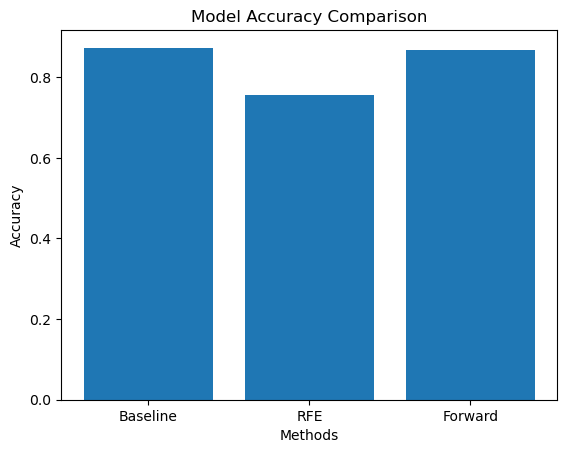

In [67]:
methods = ['Baseline', 'RFE', 'Forward']
accuracies = [baseline_acc, rfe_acc, forward_acc]

plt.figure()

plt.bar(methods, accuracies)

plt.xlabel("Methods")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()